<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Parametric_vs_NonParametric_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parametric vs Non-Parametric Tests

Every test we've learned so far (t-test, chi-square, Pearson correlation) makes assumptions about the data. When real data refuses to play nice — small samples, skew, outliers, ordinal responses — those assumptions break and our p-values become untrustworthy. The fix is a family of tests that don't make those assumptions: **non-parametric tests**.

Tonight you'll learn three of the most important ones — Mann-Whitney U, Wilcoxon signed-rank, and Fisher's exact — and walk out with a decision tree that tells you exactly when to reach for which test.

## Where we're starting · where we're going

| | |
|---|---|
| **Starting from** | t-test for means, chi-square for frequencies — every test has an assumption list. |
| **Heading to** | Tools that work *when* those assumption lists fail. |
| **The link** | The hypothesis-testing skeleton is the same: H₀ → statistic → p-value → decision. Only the statistic changes. |
| **Goal by end of session** | Run all four tests on real data and know — by reading the data — which test to reach for. |

## Setup

Two real datasets tonight. Both are well-known in statistics education.

**Palmer Penguins** — 344 penguins observed on three Antarctic islands. Comes built into `seaborn`, no download needed.

**Cushny & Peebles (1905) sleep study** — 10 patients each tried two soporific drugs; the recorded value is *extra hours of sleep*. This is the dataset Student used in 1908 to introduce the t-test. We type it in as a small DataFrame.

Run the setup cell once.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, shapiro, mannwhitneyu, wilcoxon, fisher_exact

# Penguins (Palmer Antarctic data, via seaborn)
penguins = sns.load_dataset('penguins').dropna()
print(f'Penguins  -  {len(penguins)} rows after dropping NAs')

# Cushny & Peebles 1905 sleep study
sleep = pd.DataFrame({
    'patient': range(1, 11),
    'drug_1':  [ 0.7, -1.6, -0.2, -1.2, -0.1, 3.4, 3.7, 0.8, 0.0, 2.0],
    'drug_2':  [ 1.9,  0.8,  1.1,  0.1, -0.1, 4.4, 5.5, 1.6, 4.6, 3.4],
})
print(f'Sleep     -  {len(sleep)} patients, two drugs each')

Penguins  -  333 rows after dropping NAs
Sleep     -  10 patients, two drugs each


In [5]:
# Take a quick look at the penguins data
# - show penguins.head()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## The chi-square sibling - Test of Homogeneity

Yesterday we ran the Test of Independence (one sample, two variables). Tonight, before we move to non-parametric tests, we tackle its sibling: the **Test of Homogeneity** (multiple samples, one variable).

The two questions sound similar but the design is different:

| | Independence (Yesterday) | Homogeneity (now) |
|---|---|---|
| Sampling | ONE sample, observed on two categorical variables | SEVERAL samples, each from a different population, observed on the same categorical variable |
| Question | Are these two variables related? | Do these populations share the same distribution? |
| Example | One sample of customers — is payment method related to completion? | Customers from Nairobi, Mombasa, Kisumu — do they have the same payment-method distribution? |

The maths is identical: same `χ²` statistic, same `(r-1)(c-1)` degrees of freedom, same `chi2_contingency` function. Only the research question changes.

**Penguins example:** We have three islands — Biscoe, Dream, Torgersen. Each acts like a separate population. Is the species distribution (Adelie, Chinstrap, Gentoo) the same on every island?

In [3]:
# Build the contingency table for Homogeneity
# - rows = island, columns = species
# - use pd.crosstab(penguins['island'], penguins['species'])
cont = pd.crosstab(penguins['island'], penguins['species'])
cont

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,119
Dream,55,68,0
Torgersen,47,0,0


In [9]:
# Run the chi-square Test of Homogeneity
# - chi2_contingency(ct_homog) returns (chi2, p, dof, expected)
# - print chi-square, dof, p-value
# - compare p to 0.05 and print the conclusion
chi2, p, dof, expected = chi2_contingency(cont)
print:(f"p_value: {p:.7f}")

In [11]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


The result is unambiguous — the three islands have very different species compositions (Gentoo only on Biscoe, Chinstrap only on Dream, Adelie on all three). The species distribution is **not homogeneous** across the populations.

## The assumptions every parametric test makes

A t-test, ANOVA, or Pearson correlation only gives valid p-values when the data meets five conditions:

1. **Normality** — the data (or the sampling distribution of the mean) is bell-shaped.
2. **Independence** — one observation doesn't influence another.
3. **Equal variance** — the spread is similar across groups being compared.
4. **Measurement level** — interval or ratio data, where arithmetic is meaningful.
5. **Random sampling** — the sample isn't systematically biased.

When even one of these fails, your t-test's p-value can be misleading. The non-parametric family steps in to handle exactly those cases.

The most commonly violated assumption is **normality** — which we can test directly. Shapiro-Wilk gives us a p-value: if it's small (< 0.05), the data significantly departs from normal.

In [15]:
# Check normality of Adelie body mass by sex
# - filter penguins to species == 'Adelie' -> adelie
# - get mass_M (Male) and mass_F (Female) body_mass_g columns
# - run shapiro(mass_M) and shapiro(mass_F)
# - print whether each is normal (p >= 0.05) or not
adelie = penguins[penguins['species'] == 'Adelie' ]
mass_M = adelie[adelie['sex'] == 'Male' ]['body_mass_g']
mass_F = adelie[adelie['sex'] == 'Female' ]['body_mass_g']


In [16]:
stat_M, p_M = shapiro(mass_M)
p_M

np.float64(0.4159823799821582)

In [18]:
stat_M, p_F = shapiro(mass_F)
p_F

np.float64(0.19853027779519866)

(array([ 2.,  7.,  7., 13., 10.,  8., 11.,  7.,  3.,  5.]),
 array([3325., 3470., 3615., 3760., 3905., 4050., 4195., 4340., 4485.,
        4630., 4775.]),
 <BarContainer object of 10 artists>)

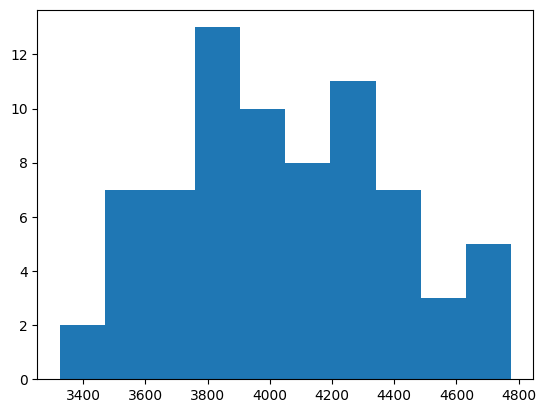

In [20]:
plt.hist(mass_M)

Body mass passes the normality check here — but this isn't always so neat with real data. We'll use Mann-Whitney U regardless (treating it as a robust alternative). The lesson is *how to check*, not just *what to do when assumptions hold*.

## The key idea — work with ranks, not raw values

A t-test compares **raw values**: `t = (mean_difference) / (standard_error)`. If the raw values are skewed or have outliers, the standard error is misleading and so is `t`.

A non-parametric test does something different: it **ranks** the values first, then compares ranks.

Say two groups produce these values:

```
Group A:  3.2,  4.1,  5.0,  6.3,  9.8
Group B:  2.1,  3.8,  4.5,  5.7,  100
```

A t-test would see Group B's mean dragged up by the outlier (100). A rank-based test converts the values to their position in the sorted order:

```
Group A ranks:  3,  5,  7,  8,  9
Group B ranks:  1,  4,  6,  8,  10
```

The 100 becomes "rank 10" — no longer a destructive force. The test asks: "do Group A's ranks tend to be higher or lower than Group B's?" That question is robust to outliers, skew, and most non-normality.

That single idea — **work with ranks** — powers Mann-Whitney U, Wilcoxon signed-rank, and Kruskal-Wallis.

## Mann-Whitney U — two independent groups

The non-parametric replacement for the independent-samples t-test. Use it when you have two independent groups and you can't trust their normality.

**Penguins question:** *Do male and female Adelie penguins have different body masses?*

In [23]:
# Run Mann-Whitney U on Adelie body mass by sex
# - call mannwhitneyu(mass_M, mass_F, alternative='two-sided')
# - print U statistic, p-value
# - print medians of both groups
# - compare p to 0.05 and print the conclusion
stat, p =mannwhitneyu(mass_M, mass_F, alternative = 'two-sided')
p

np.float64(3.091126679230123e-20)

In [ ]:
# Plot body mass by sex as a boxplot
# - use sns.boxplot with x='sex', y='body_mass_g'
# - colors: navy '#1B2A4A' for male, orange '#F26522' for female


## Wilcoxon signed-rank — paired data

The non-parametric replacement for the paired t-test. Use it when you have the **same subjects** measured **twice** (before/after, treatment A vs treatment B, etc.) and the differences between the two measurements aren't normally distributed.

**Sleep-study question:** *Among these 10 patients, does Drug 2 produce more extra sleep than Drug 1?*

With only 10 patients we can't trust any normality assumption anyway — small samples are exactly when non-parametric methods earn their keep.

In [ ]:
# Look at the sleep dataset
# - just display the DataFrame


In [ ]:
# Look at the sleep dataset
# - just display the DataFrame


In [ ]:
# Look at the sleep dataset
# - just display the DataFrame


In [ ]:
# Look at the sleep dataset
# - just display the DataFrame


## Fisher's exact — small contingency tables

When a chi-square test's "expected count ≥ 5" rule fails — typically with small samples — Fisher's exact takes over. It computes the *exact* p-value by enumerating every possible 2×2 table with the same row and column totals.

Alongside the p-value, Fisher's exact gives you the **odds ratio** — the effect-size companion for 2×2 tables. An odds ratio of 1 means no relationship; > 1 means the variables are positively associated; < 1 means negatively associated.

**Penguins question:** Take a *small random sample* of 30 penguins (simulating a real study with budget limits). Is sex independent of species in this small sample?

In [ ]:
# Build a small 2x2 for Fisher's exact
# - set np.random.seed(42)
# - filter penguins to species in ['Adelie', 'Chinstrap']
# - take a random sample of n=30 (random_state=42)
# - cross-tab species x sex to get a 2x2 contingency table
# - print it


In [ ]:
# Run Fisher's exact test on the 2x2
# - fisher_exact(ct_small.values) returns (odds_ratio, p_value)
# - print both
# - compare p to 0.05 and print the conclusion


## The decision tree — given any dataset, which test?

Pin this above your desk.

```
Is your data CATEGORICAL?
├─ Yes →  All expected counts ≥ 5 ?
│         ├─ Yes →  Chi-square (Goodness of Fit, Independence, or Homogeneity)
│         └─ No  →  Fisher's exact
│
└─ No (numerical) →  How many groups?
                     ├─ 1 group → Is data normal?
                     │            ├─ Yes → One-sample t-test
                     │            └─ No  → Wilcoxon signed-rank
                     │
                     ├─ 2 groups (independent) → Are both groups normal?
                     │                          ├─ Yes → Independent-samples t-test
                     │                          └─ No  → Mann-Whitney U
                     │
                     ├─ 2 groups (paired) → Are the differences normal?
                     │                     ├─ Yes → Paired t-test
                     │                     └─ No  → Wilcoxon signed-rank
                     │
                     └─ 3+ groups → Are all groups normal?
                                   ├─ Yes → ANOVA
                                   └─ No  → Kruskal-Wallis
```

In English: ask three questions in this order — *what kind of data, how many groups, do assumptions hold?* — and the right test falls out.

## What we tell our clients

Four findings, four real datasets:

1. **Homogeneity** — Penguin species distribution is *very different* across the three islands. Conservation efforts on a per-island basis make sense.
2. **Mann-Whitney U** — Adelie males weigh more than Adelie females. The difference is statistically significant and biologically real.
3. **Wilcoxon signed-rank** — Drug 2 produces more extra sleep than Drug 1, in the same patients. The effect is real even with just 10 patients.
4. **Fisher's exact** — In our small 30-bird sub-study, species and sex appear roughly independent. We'd need more data to make a stronger claim.

The pattern across all four: *real data, real tests, real answers.*